#    Wildcard Challenge #1



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

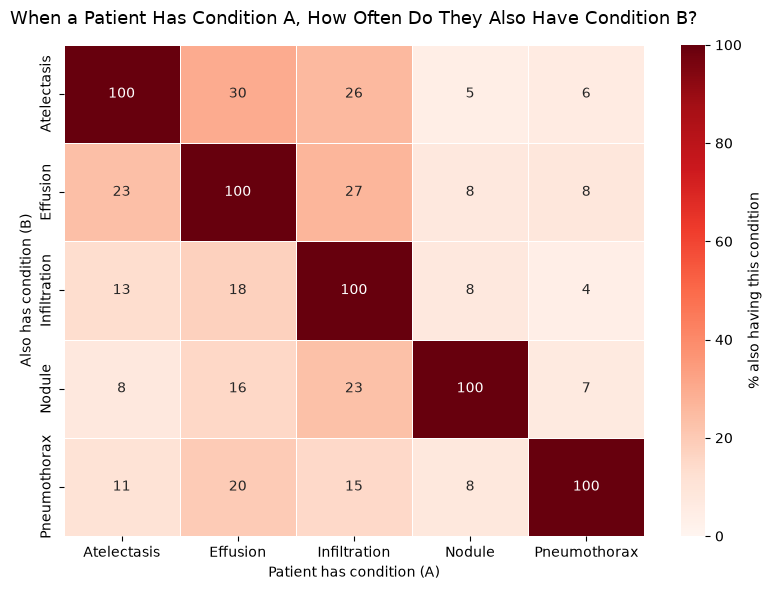

In [3]:
df = pd.read_csv('../code/train_labels.csv')
conditions = ['Atelectasis', 'Effusion', 'Infiltration', 'Nodule', 'Pneumothorax']

#Create an empty DataFrame with conditions (5x5) as both rows and columns.
cooc = pd.DataFrame(index=conditions, columns=conditions, dtype=float)

for x in conditions:    #x -> condition A
    x_1 = df[df[x] == 1]    #Here x_1 is list of images for which 'x' i.e condition A = 1
    Patients_A = len(x_1)   #Patients_A -> total no. of patients having condition A
    for y in conditions:    #y -> condition B (Patient is confirmed for condition A)
        if Patients_A == 0:
            cooc.loc[x, y] = 0
        else:
            cooc.loc[x, y] = (x_1[y].sum() / Patients_A) * 100
                #Calculates the percentage of Condition A patients who also have Condition B i.e P(A/B)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cooc.astype(float),
    annot=True, fmt=".0f",  #Round to nearest whole no.
    cmap="Reds", vmin=0, vmax=100,  #light - 0% and dark - 100%
    cbar_kws={'label': '% also having this condition'}, #Label for the color bar on the right
    linewidths=0.5, linecolor='white'
)
plt.title("When a Patient Has Condition A, How Often Do They Also Have Condition B?",fontsize=13, pad=15)
plt.xlabel("Patient has condition (A)")
plt.ylabel("Also has condition (B)")
plt.tight_layout()
plt.show()

### This heatmap shows how often patients with one lung condition also present with another, based on 4,000 chest X-ray records. For example, patients diagnosed with Effusion frequently also show signs of Infiltration — meaning care teams reviewing an Effusion case should routinely screen for Atelectasis too, rather than treating each finding in isolation. Recognizing these overlaps early can help hospitals plan more efficient combined-review workflows instead of single-condition triage.